In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('/home/ahmed/Desktop/datascince/prj /Project Data/kmeans_employee_dirty_dataset.csv')

In [3]:
df.head()

,Employee_ID,Experience_Years,Age,Department,Salary,Employees
0,81,8.2,NaN,Finance,95000.0,43.0
1,143,1.2,NaN,NaN,61700.0,84.0
2,77,5.5,31.0,IT,94300.0,51.0
3,156,10.0,45.0,Management,180900.0,19.0
4,87,7.1,37.0,Finance,86100.0,29.0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       180 non-null    int64  
 1   Experience_Years  174 non-null    float64
 2   Age               175 non-null    float64
 3   Department        177 non-null    str    
 4   Salary            174 non-null    float64
 5   Employees         176 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 8.6 KB


In [5]:
df.describe()

,Employee_ID,Experience_Years,Age,Salary,Employees
count,180.000000,174.000000,175.000000,174.000000,176.000000
mean,85.883333,5.868391,32.051429,82829.885057,41.153409
std,49.122953,3.334403,7.396231,37034.700538,21.051075
min,1.000000,0.300000,20.000000,22200.000000,8.000000
25%,44.750000,3.225000,26.000000,53950.000000,20.000000
50%,85.500000,5.250000,31.000000,80400.000000,39.000000
75%,127.250000,7.950000,37.000000,105050.000000,59.000000
max,172.000000,16.000000,52.000000,194900.000000,89.000000


In [7]:
df.isnull().sum()

Employee_ID         0
Experience_Years    6
Age                 5
Department          3
Salary              6
Employees           4
dtype: int64

In [12]:
df.dtypes

Employee_ID           int64
Experience_Years    float64
Age                 float64
Department              str
Salary              float64
Employees           float64
dtype: object

In [8]:
df.duplicated().sum()

np.int64(6)

In [9]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Department'].fillna(df['Department'].mode(), inplace=True)

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

/tmp/ipykernel_2244/2839896944.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Department'].fillna(df['Department'].mode(), inplace=True)


In [20]:
le = LabelEncoder()

df["Department"] = le.fit_transform (df['Department'])


In [17]:
df = df.drop('Employee_ID', axis=1)

In [ ]:
X = df[[
    "Experience_Years",
    "Age",
    "Department",
    "Salary",
    "Employees" ]]

X.head()

,Experience_Years,Age,Department,Salary,Employees
0,8.2,31.994083,0,95000.0,43.0
1,1.2,31.994083,5,61700.0,84.0
2,5.5,31.000000,2,94300.0,51.0
3,10.0,45.000000,3,180900.0,19.0
4,7.1,37.000000,0,86100.0,29.0


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

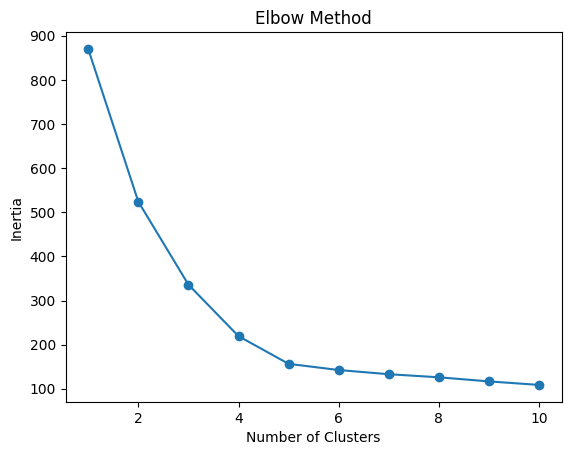

In [28]:
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [31]:
df.head()

,Experience_Years,Age,Department,Salary,Employees,Cluster
0,8.2,31.994083,0,95000.0,43.0,1
1,1.2,31.994083,5,61700.0,84.0,2
2,5.5,31.000000,2,94300.0,51.0,2
3,10.0,45.000000,3,180900.0,19.0,1
4,7.1,37.000000,0,86100.0,29.0,1


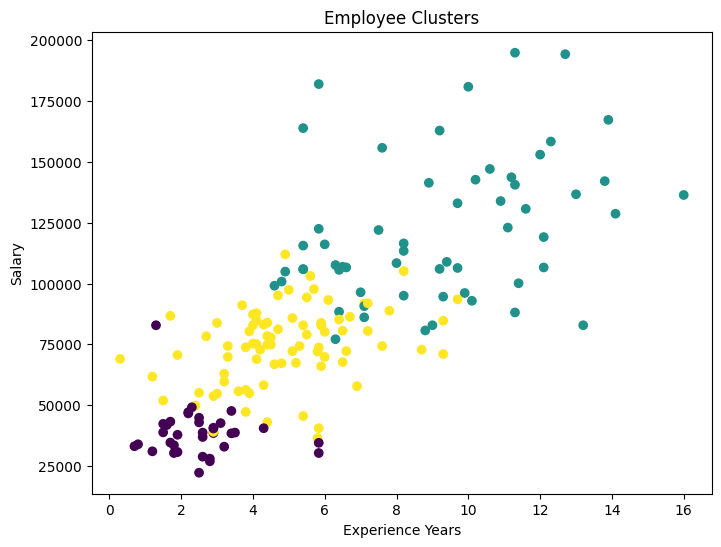

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Experience_Years"],
    df["Salary"],
    c=df["Cluster"]
)

plt.xlabel("Experience Years")

plt.ylabel("Salary")

plt.title("Employee Clusters")

plt.show()

In [34]:
df["Cluster"].value_counts()

Cluster
2    81
1    58
0    35
Name: count, dtype: int64

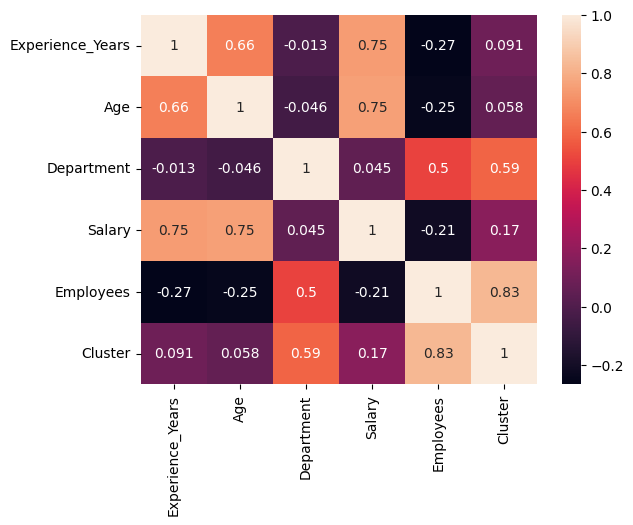

In [43]:
sns.heatmap(df.corr(), annot=True)
plt.show()